In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Universe Setup ---
tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'BRK-B', 'V', 'UNH',
    'JNJ', 'XOM', 'WMT', 'PG', 'JPM', 'MA', 'LLY', 'CVX', 'HD', 'ABBV',
    'ORCL', 'KO', 'PEP', 'BAC', 'AVGO', 'COST', 'ADI', 'GS', 'BLK', 'LMT',
    'AMT', 'EQIX', 'ISRG', 'MDT', 'TJX', 'PFE', 'ABT', 'DIS', 'NFLX', 'CAT',
    'UPS', 'HON', 'TXN', 'MS', 'NEE', 'PM', 'RTX', 'LOW', 'AMGN', 'INTC'
]
benchmark = '^GSPC'

start_date = '2016-01-01'
end_date = '2026-03-25'

# --- Step-by-Step Robust Download ---
print(f"Downloading data for {len(tickers)} assets...")
# Force auto_adjust=False to ensure 'Adj Close' is requested
raw_data = yf.download(tickers + [benchmark], start=start_date, end=end_date, auto_adjust=False)

# Diagnostic: Check what we actually got
# If 'Adj Close' isn't in level 0, we fallback to 'Close'
if 'Adj Close' in raw_data.columns.get_level_values(0):
    prices_all = raw_data['Adj Close']
    print("Successfully extracted 'Adj Close'.")
elif 'Close' in raw_data.columns.get_level_values(0):
    prices_all = raw_data['Close']
    print("Warning: 'Adj Close' not found. Using 'Close' instead.")
else:
    raise KeyError("Could not find price data in the downloaded object. Check your internet or tickers.")

# --- Integrity Check & Filtering ---
# Keep columns with at least 90% data to handle younger stocks
threshold = len(prices_all) * 0.9
valid_prices = prices_all.dropna(axis=1, thresh=threshold)

# Finalize stock and benchmark dataframes
available_stocks = [t for t in tickers if t in valid_prices.columns]
prices = valid_prices[available_stocks].ffill().bfill() # Gap filling
bench_prices = valid_prices[benchmark].ffill().bfill()

# --- Log Returns Calculation ---
log_returns = np.log(prices / prices.shift(1)).dropna()
bench_returns = np.log(bench_prices / bench_prices.shift(1)).dropna()

print(f"\n--- Data Summary ---")
print(f"Assets loaded: {len(available_stocks)} stocks + 1 benchmark")
print(f"Data range: {log_returns.index[0].date()} to {log_returns.index[-1].date()}")

[*********************100%***********************]  51 of 51 completed

Successfully extracted 'Adj Close'.

--- Data Summary ---
Assets loaded: 50 stocks + 1 benchmark
Data range: 2016-01-05 to 2026-03-24


<Figure size 1500x1200 with 0 Axes>

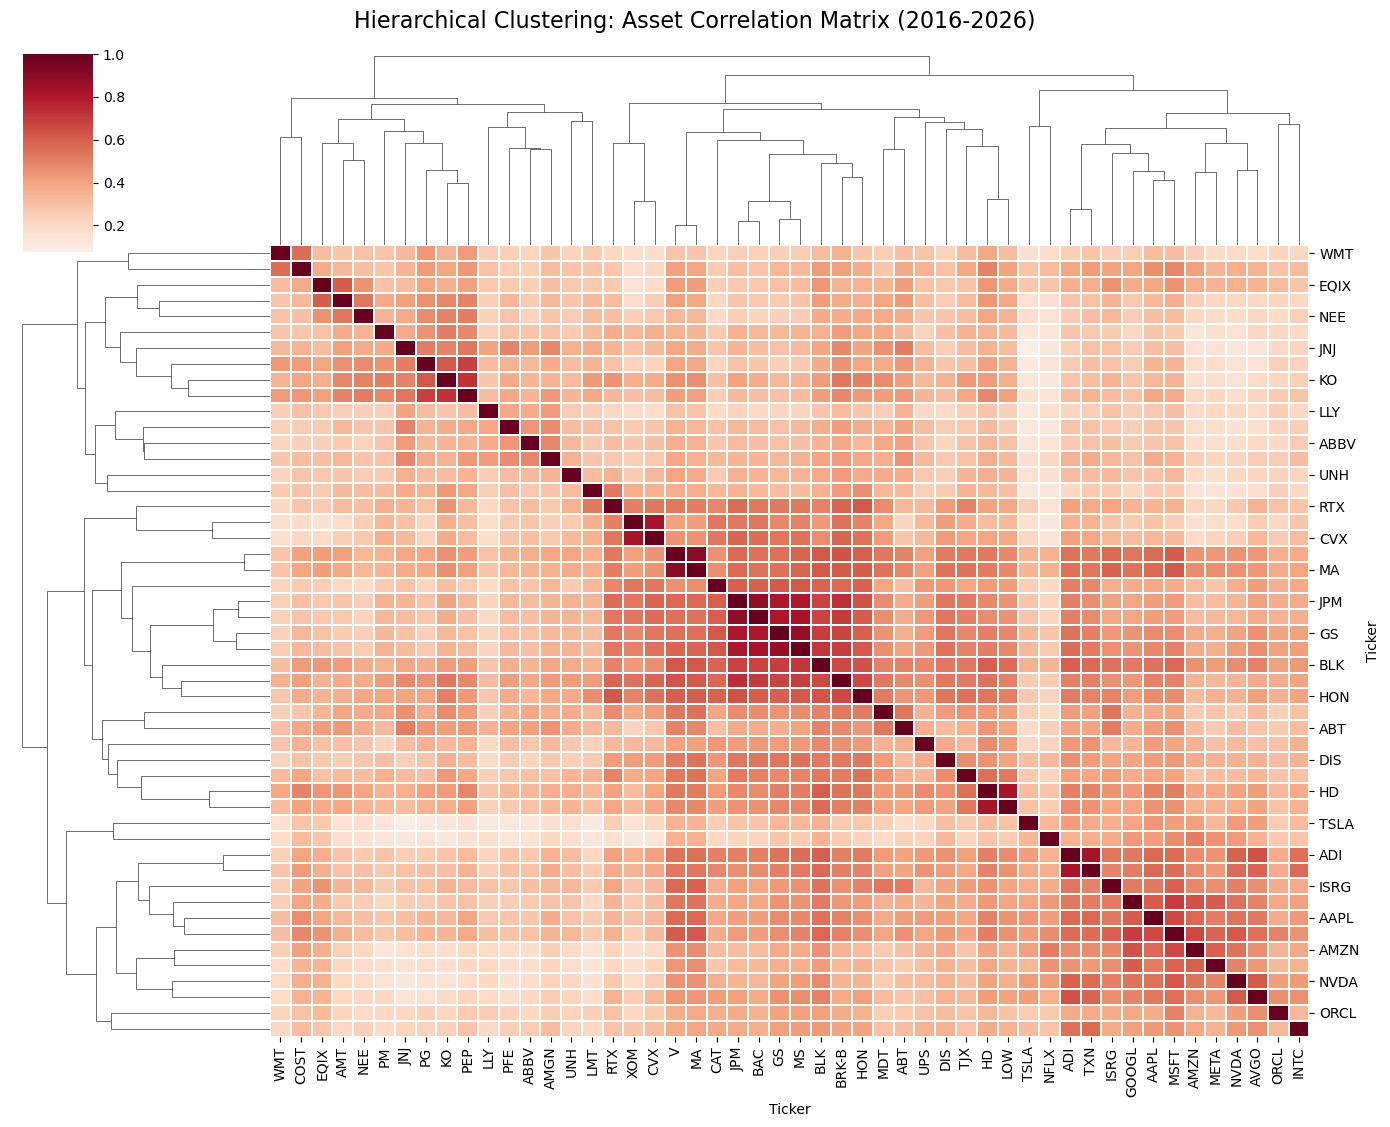

--- Portfolio Risk Diagnostics (Equal Weight) ---
Systematic Exposure (Portfolio Beta): 0.9536
Diversification Ratio: 1.6297
Total Portfolio Volatility (Annualized): 17.58%


In [2]:
# --- 1. Variance-Covariance (Annualized) ---
cov_matrix = log_returns.cov() * 252
corr_matrix = log_returns.corr()

# --- 2. Hierarchical Cluster Map ---
# This is much more insightful than a standard heatmap for 50 assets
plt.figure(figsize=(15, 12))
# Using 'RdBu_r' color map to show positive/negative correlations clearly
cluster_grid = sns.clustermap(corr_matrix, cmap='RdBu_r', center=0, annot=False, 
                              linewidths=.1, figsize=(14, 11))
plt.suptitle('Hierarchical Clustering: Asset Correlation Matrix (2016-2026)', fontsize=16, y=1.02)
plt.show()

# --- 3. Naive Portfolio Metrics (Equal Weight Baseline) ---
n = len(available_stocks)
weights = np.array([1/n] * n)

# Realized Beta via Covariance logic
# Beta = Cov(Rp, Rm) / Var(Rm)
portfolio_rets = log_returns.dot(weights)
beta = np.cov(portfolio_rets, bench_returns)[0, 1] / bench_returns.var()

# Diversification Ratio (DR)
# Ratio of weighted average volatility to actual portfolio volatility
vols = np.sqrt(np.diag(cov_matrix))
weighted_avg_vol = np.sum(weights * vols)
portfolio_vol = np.sqrt(weights.T @ cov_matrix @ weights)
dr = weighted_avg_vol / portfolio_vol

print(f"--- Portfolio Risk Diagnostics (Equal Weight) ---")
print(f"Systematic Exposure (Portfolio Beta): {beta:.4f}")
print(f"Diversification Ratio: {dr:.4f}")
print(f"Total Portfolio Volatility (Annualized): {portfolio_vol:.2%}")

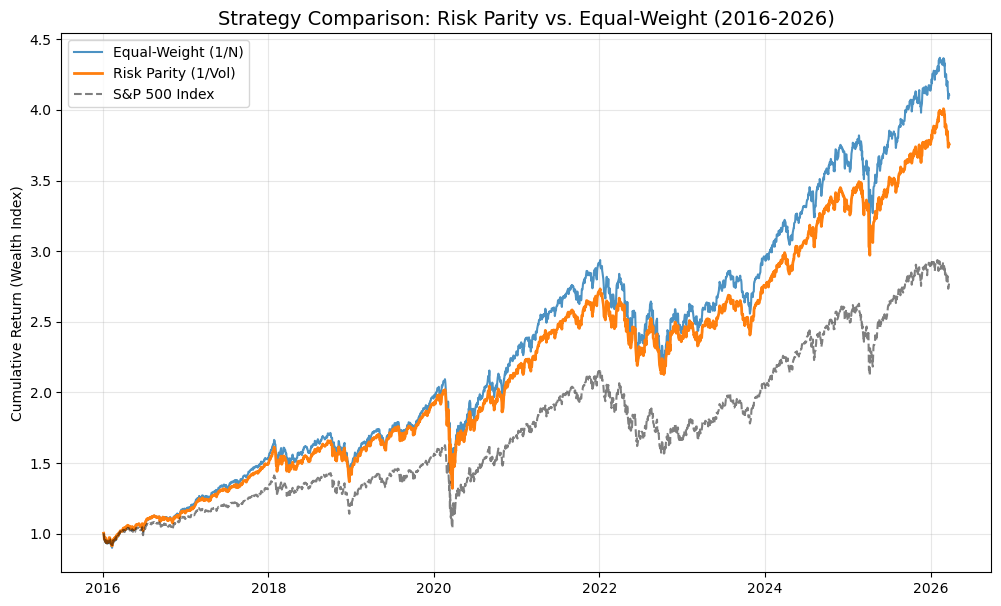


--- Strategy Performance Summary ---
                    Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown
Strategy                                                                 
Equal-Weight (1/N)       15.42%          17.58%         0.88      -35.25%
Risk Parity (1/Vol)      14.40%          16.73%         0.86      -34.61%
S&P 500 Index            11.58%          18.08%         0.64      -36.10%


In [3]:
# --- 1. Weight Calculation ---
# Equal Weight (EW): 1/N for all assets
n_assets = len(available_stocks)
weights_ew = np.repeat(1/n_assets, n_assets)

# Simple Risk Parity (RP): Weights inversely proportional to volatility
# We use the annualized standard deviation (sigma) from Task 1
individual_vols = log_returns.std() * np.sqrt(252)
inv_vols = 1 / individual_vols
weights_rp = inv_vols / np.sum(inv_vols) # Normalizing to sum to 1.0

# --- 2. Portfolio Performance Attribution ---
# Calculating the time-series of returns for both strategies
# Using simple dot product of returns matrix and weight vectors
returns_ew = log_returns.dot(weights_ew)
returns_rp = log_returns.dot(weights_rp)

# --- 3. Cumulative Returns (Equity Curves) ---
# Compounding the daily returns to visualize growth of $1
equity_ew = (1 + returns_ew).cumprod()
equity_rp = (1 + returns_rp).cumprod()
equity_bench = (1 + bench_returns).cumprod()

# --- 4. Performance Metrics Comparison ---
def get_metrics(rets, name):
    ann_ret = rets.mean() * 252
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol
    max_dd = ((1 + rets).cumprod() / (1 + rets).cumprod().cummax() - 1).min()
    return {
        'Strategy': name,
        'Ann. Return': f"{ann_ret:.2%}",
        'Ann. Volatility': f"{ann_vol:.2%}",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Max Drawdown': f"{max_dd:.2%}"
    }

stats = [
    get_metrics(returns_ew, 'Equal-Weight (1/N)'),
    get_metrics(returns_rp, 'Risk Parity (1/Vol)'),
    get_metrics(bench_returns, 'S&P 500 Index')
]

# --- 5. Visualization ---
plt.figure(figsize=(12, 7))
plt.plot(equity_ew, label='Equal-Weight (1/N)', alpha=0.8)
plt.plot(equity_rp, label='Risk Parity (1/Vol)', linewidth=2)
plt.plot(equity_bench, label='S&P 500 Index', linestyle='--', color='black', alpha=0.5)
plt.title('Strategy Comparison: Risk Parity vs. Equal-Weight (2016-2026)', fontsize=14)
plt.ylabel('Cumulative Return (Wealth Index)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- Strategy Performance Summary ---")
print(pd.DataFrame(stats).set_index('Strategy'))

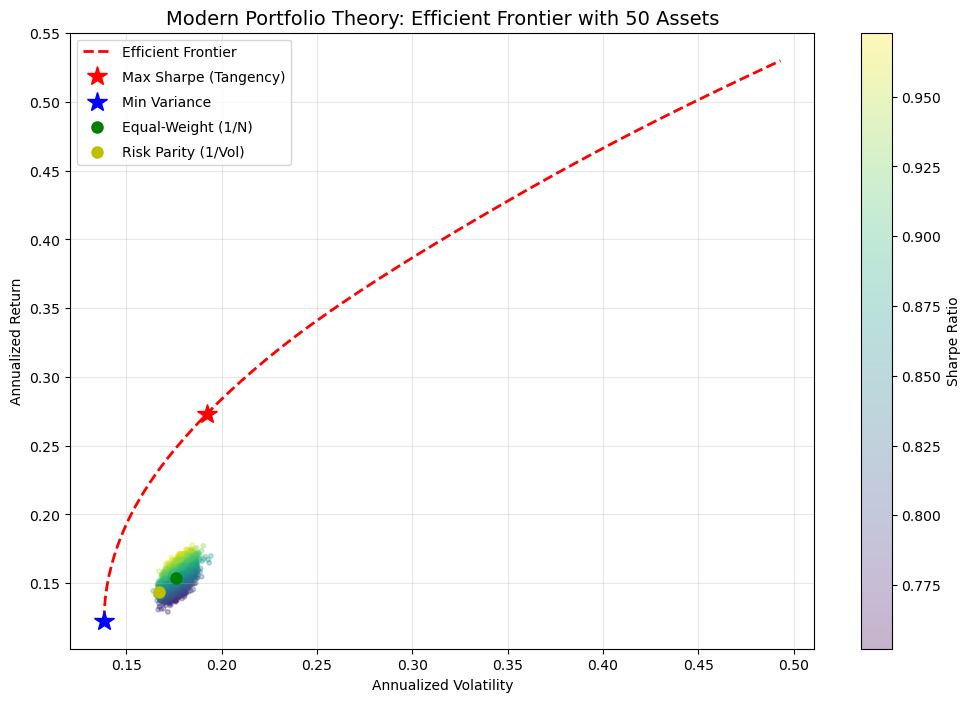


--- Final Framework Comparison ---
                    Ann. Return Ann. Volatility Sharpe Ratio     Max Drawdown
Strategy                                                                     
Equal-Weight (1/N)       15.42%          17.58%         0.88          -35.25%
Risk Parity (1/Vol)      14.40%          16.73%         0.86          -34.61%
MVO Max Sharpe           27.33%          19.22%         1.42  N/A (In-sample)


In [4]:
import scipy.optimize as sco

# --- 1. Parameter Estimation (Annualized) ---
# mu: Vector of expected returns (using historical arithmetic mean)
# sigma: Covariance matrix (annualized)
mu = log_returns.mean() * 252
sigma = log_returns.cov() * 252
num_assets = len(available_stocks)

# --- 2. Portfolio Utility Functions ---
def get_port_stats(weights):
    """Returns [Expected Return, Volatility, Sharpe Ratio]"""
    weights = np.array(weights)
    port_ret = np.sum(mu * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
    return np.array([port_ret, port_vol, port_ret / port_vol])

def min_func_sharpe(weights):
    # Minimizing negative Sharpe = Maximizing Sharpe
    return -get_port_stats(weights)[2]

def min_func_volatility(weights):
    return get_port_stats(weights)[1]

# --- 3. Constraints & Optimization ---
# Budget Constraint: sum(weights) = 1
# Long-only Constraint: 0 <= weight <= 1
cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bnds = tuple((0, 1) for _ in range(num_assets))
init_guess = num_assets * [1. / num_assets]

# A. Optimize for Max Sharpe Ratio (Tangency Portfolio)
opts = sco.minimize(min_func_sharpe, init_guess, method='SLSQP', bounds=bnds, constraints=cons)
w_max_sharpe = opts['x']

# B. Optimize for Minimum Variance Portfolio (MVP)
optv = sco.minimize(min_func_volatility, init_guess, method='SLSQP', bounds=bnds, constraints=cons)
w_min_var = optv['x']

# --- 4. Generating the Efficient Frontier ---
# We solve for the minimum volatility at each target return level
target_returns = np.linspace(get_port_stats(w_min_var)[0], mu.max(), 50)
efficient_vols = []
for tr in target_returns:
    cons_ef = ({'type': 'eq', 'fun': lambda x: get_port_stats(x)[0] - tr},
               {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    res = sco.minimize(min_func_volatility, init_guess, method='SLSQP', bounds=bnds, constraints=cons_ef)
    efficient_vols.append(res['fun'])

# --- 5. Monte Carlo Simulation for Feasible Set ---
# Generating 5000 random portfolios to visualize the distribution
n_sim = 5000
sim_results = np.zeros((3, n_sim))
for i in range(n_sim):
    w = np.random.random(num_assets)
    w /= np.sum(w)
    sim_results[:, i] = get_port_stats(w)

# --- 6. Visualization ---
plt.figure(figsize=(12, 8))
# Random portfolio cloud
plt.scatter(sim_results[1,:], sim_results[0,:], c=sim_results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3)
# Efficient Frontier Line
plt.plot(efficient_vols, target_returns, 'r--', linewidth=2, label='Efficient Frontier')
# Highlight Key Portfolios
plt.plot(get_port_stats(w_max_sharpe)[1], get_port_stats(w_max_sharpe)[0], 'r*', markersize=15.0, label='Max Sharpe (Tangency)')
plt.plot(get_port_stats(w_min_var)[1], get_port_stats(w_min_var)[0], 'b*', markersize=15.0, label='Min Variance')
# Plotting Task 2 strategies for comparison
plt.plot(get_port_stats(weights_ew)[1], get_port_stats(weights_ew)[0], 'go', markersize=8, label='Equal-Weight (1/N)')
plt.plot(get_port_stats(weights_rp)[1], get_port_stats(weights_rp)[0], 'yo', markersize=8, label='Risk Parity (1/Vol)')

plt.title('Modern Portfolio Theory: Efficient Frontier with 50 Assets', fontsize=14)
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.colorbar(label='Sharpe Ratio')
plt.legend(labelspacing=0.8)
plt.grid(True, alpha=0.3)
plt.show()

# --- 7. Portfolio Allocation Report ---
mvo_stats = [
    get_metrics(returns_ew, 'Equal-Weight (1/N)'), # Re-using Task 2 function
    get_metrics(returns_rp, 'Risk Parity (1/Vol)'),
    {
        'Strategy': 'MVO Max Sharpe',
        'Ann. Return': f"{get_port_stats(w_max_sharpe)[0]:.2%}",
        'Ann. Volatility': f"{get_port_stats(w_max_sharpe)[1]:.2%}",
        'Sharpe Ratio': f"{get_port_stats(w_max_sharpe)[2]:.2f}",
        'Max Drawdown': 'N/A (In-sample)'
    }
]
print("\n--- Final Framework Comparison ---")
print(pd.DataFrame(mvo_stats).set_index('Strategy'))